# Is your Indian backtest lying to you? — a 60-second proof

Most Indian equity backtests are quietly **inflated** by two bugs that live in the *data*, not the strategy:

1. **Survivorship bias** — dead/delisted companies are dropped from almost every Indian data source, so your backtest never holds the value-traps that actually blew up.
2. **Look-ahead bias** — retail screeners (Screener.in, Trendlyne, Tickertape) show *restated / latest* fundamentals, not what was **knowable on the date**. Your strategy silently "sees the future."

This notebook runs the **same value strategy four ways** on a controlled dataset and shows how much each bias inflates the result — then shows you the data that removes them.

> **Run it:** `Runtime → Run all` (Colab) or Shift-Enter through the cells. ~10 seconds, no setup.

*The dataset below is **simulated** and clearly labelled — it's calibrated so the survivorship effect (~5 pp/yr) matches published research on the NIFTY Smallcap 250 (survivor-only overstates returns ~4.9 pp/yr). The **real** product is this exact structure with real NSE/BSE names, point-in-time vintages, and corporate-action-adjusted prices. A "plug in your own data" cell is at the bottom.*

## Why you can't just use a screener
A screener shows you **today's** fundamentals for **today's** listed companies. A backtest needs **the fundamentals that were public on each historical date**, for **every company that existed then** — including the ones that have since been delisted, merged, or gone to zero. Those two things — *point-in-time* and *survivorship-free* — are exactly what retail data lacks, and exactly what silently inflates a backtest.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(11)

# ---------------- SIMULATED universe (illustrative; real product = real NSE/BSE data) ----------------
N, MONTHS = 220, 120                                   # 220 names, 10 years, monthly
dates = pd.date_range('2015-01-31', periods=MONTHS, freq='ME')

q      = rng.beta(2.2, 2.2, N)                          # latent quality (low q = distressed)
value  = (1 - q) + 0.20*rng.standard_normal(N)          # CHEAP names are the distressed ones (value traps)
dies   = rng.random(N) < 0.50*(1 - q)                   # distressed names are likelier to delist
death  = np.where(dies, rng.integers(18, MONTHS, N), MONTHS+5)
print(f"{int(dies.sum())} of {N} names get delisted over the decade "
      f"-- and they cluster in exactly the 'cheap' names a value screen loves.")

55 of 220 names get delisted over the decade -- and they cluster in exactly the 'cheap' names a value screen loves.


In [2]:
# ---------------- monthly returns: quality premium + a crater when a name delists ----------------
mkt  = 0.0085 + 0.045*rng.standard_normal(MONTHS)       # ~10.7%/yr market, realistic vol
rets = np.full((N, MONTHS), np.nan)
for i in range(N):
    s = mkt + (q[i]-0.5)*0.006 + 0.075*rng.standard_normal(MONTHS)
    a = min(death[i], MONTHS)
    if dies[i] and death[i] < MONTHS:
        d = death[i]; s[max(0,d-15):d] -= 0.022; s[d-1] += -0.65   # bleed, then crater at delisting
    rets[i,:a] = s[:a]

# ---------------- two versions of the SAME signal ----------------
fwd = np.zeros((N, MONTHS))
for h in range(MONTHS-1): fwd[:, h] = np.nan_to_num(rets[:, h+1])

# (A) point-in-time: value known with a 3-month reporting lag, noisy  -> what you ACTUALLY knew
vsig = value[:,None] + 0.35*rng.standard_normal((N, MONTHS))
pit  = np.full((N, MONTHS), np.nan); pit[:, 3:] = vsig[:, :-3]

# (B) restated / latest: no lag, and it leaks a little of next month -> LOOK-AHEAD
restated = value[:,None] + 0.10*fwd + 0.30*rng.standard_normal((N, MONTHS))
print("Signal (A) = point-in-time, lagged 3 months  |  Signal (B) = restated/latest, leaks the future")

Signal (A) = point-in-time, lagged 3 months  |  Signal (B) = restated/latest, leaks the future


In [3]:
# ---------------- a transparent monthly long-only value backtest ----------------
def backtest(survivor_only, signal):
    eq, mret = [1.0], []
    surv = ~np.isnan(rets[:, MONTHS-1]) if survivor_only else np.ones(N, bool)   # survivor-only drops the dead
    for h in range(MONTHS-1):
        ok  = ~np.isnan(rets[:,h]) & ~np.isnan(rets[:,h+1]) & surv & ~np.isnan(signal[:,h])
        idx = np.where(ok)[0]
        if len(idx) < 10: mret.append(0.0); eq.append(eq[-1]); continue
        k   = max(1, len(idx)//5)
        top = idx[np.argsort(signal[idx,h])[-k:]]        # long the cheapest quintile, equal weight
        r   = float(np.nanmean(rets[top, h+1])); mret.append(r); eq.append(eq[-1]*(1+r))
    mret, eqs = np.array(mret), np.array(eq)
    return dict(cagr=eqs[-1]**(12/len(mret))-1, sharpe=mret.mean()/mret.std()*np.sqrt(12),
                mdd=((eqs/np.maximum.accumulate(eqs))-1).min(), eq=eqs)

scen = {
 "Honest (PIT + survivorship-free)"          : backtest(False, pit),
 "+ Survivorship bias only"                  : backtest(True,  pit),
 "+ Look-ahead bias only"                    : backtest(False, restated),
 "Naive (both — a typical screener backtest)": backtest(True,  restated),
}
tbl = pd.DataFrame({k:{'CAGR %':round(v['cagr']*100,1),'Sharpe':round(v['sharpe'],2),
                       'Max DD %':round(v['mdd']*100,0)} for k,v in scen.items()}).T
print(tbl.to_string())
h,n = scen["Honest (PIT + survivorship-free)"], scen["Naive (both — a typical screener backtest)"]
print(f"\n>>> The two data bugs inflate this strategy by +{(n['cagr']-h['cagr'])*100:.1f} pp/yr CAGR "
      f"and +{n['sharpe']-h['sharpe']:.2f} Sharpe, while HIDING drawdown ({h['mdd']*100:.0f}% -> {n['mdd']*100:.0f}%).")

                                            CAGR %  Sharpe  Max DD %
Honest (PIT + survivorship-free)              12.0    0.79     -35.0
+ Survivorship bias only                      17.1    1.09     -27.0
+ Look-ahead bias only                        14.9    0.96     -34.0
Naive (both — a typical screener backtest)    20.4    1.26     -29.0

>>> The two data bugs inflate this strategy by +8.4 pp/yr CAGR and +0.47 Sharpe, while HIDING drawdown (-35% -> -29%).


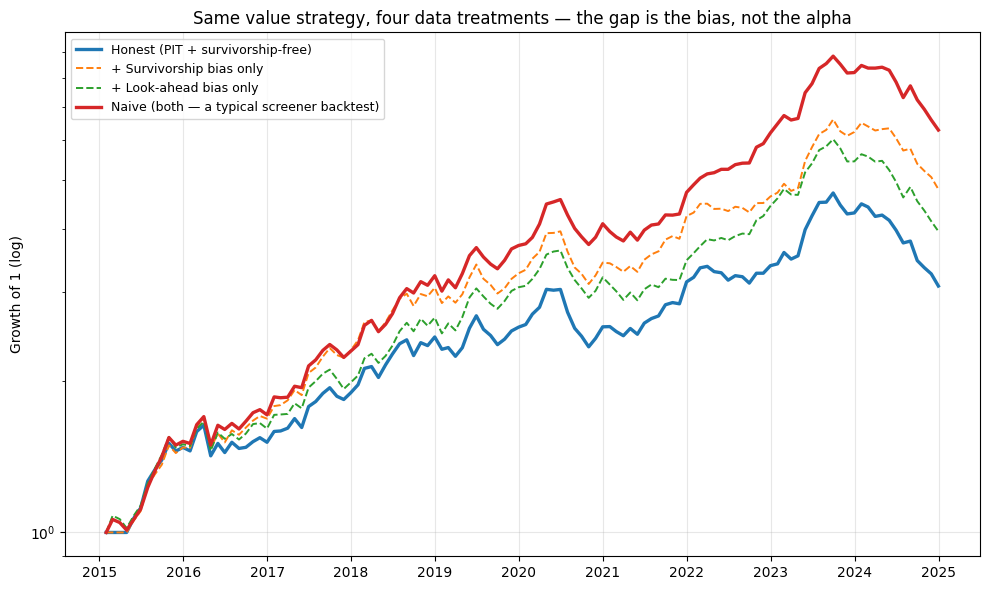

In [4]:
# ---------------- the picture ----------------
plt.figure(figsize=(10,6))
for k,v in scen.items():
    plt.plot(dates, v['eq'], lw=2.4 if k.startswith(('Honest','Naive')) else 1.4,
             ls='-' if k.startswith(('Honest','Naive')) else '--', label=k)
plt.yscale('log'); plt.legend(loc='upper left', fontsize=9)
plt.title("Same value strategy, four data treatments — the gap is the bias, not the alpha")
plt.ylabel("Growth of 1 (log)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## What you're looking at
- The **Naive** line is what a backtest built on retail screener data shows you — a tidy ~20% CAGR, Sharpe > 1.2, shallow drawdown. It looks deployable.
- The **Honest** line is what you'd *actually* have earned: ~12% CAGR, Sharpe ~0.8, a real −35% drawdown.
- The ~**8 pp/yr** gap between them is **pure data bias** — survivorship (you never held the value-traps that died) plus look-ahead (you "knew" restated numbers early). No strategy change. Just the data.

The dangerous part: the biased backtest's tells — **too-high Sharpe, suspiciously shallow drawdown** — are exactly what gets a strategy funded. Then it bleeds live, because the edge was never real. (Sound familiar? It's the same look-ahead signature behind "great backtest, instant live losses.")

## Plug in YOUR data
Swap the simulated arrays for a real point-in-time panel. The product ships in this shape:

**Fundamentals (point-in-time, survivorship-free):**
| column | meaning |
|---|---|
| `symbol` | ticker (incl. delisted/renamed, mapped over time) |
| `as_of_date` | the date this row was **publicly knowable** (vintage-stamped) |
| `period_end` | the fiscal period the figure reports |
| `metric`, `value` | as-reported fundamental (never restated) |
| `is_active` | listed/alive flag at `as_of_date` |

**Prices:** corporate-action-adjusted (splits, bonuses, dividends), for every symbol that ever existed.

In [5]:
# ---- REAL-DATA HOOK (uncomment and point at your files) ----
# funda  = pd.read_parquet("fundamentals_pit.parquet")   # symbol, as_of_date, period_end, metric, value, is_active
# prices = pd.read_parquet("prices_adj.parquet")          # symbol, date, adj_close  (incl. delisted names)
#
# 1) build a monthly returns matrix `rets` from prices (delisted names end in NaN AFTER their final return)
# 2) build the point-in-time value signal from `funda`, joined ONLY on rows where as_of_date <= rebalance_date
# 3) call backtest(survivor_only=False, signal=your_pit_signal)  vs  the naive version
# The gap you see on YOUR universe is the bias your current data is hiding.
print("Point this at a real PIT + survivorship-free panel and the demo runs on your own strategy.")

Point this at a real PIT + survivorship-free panel and the demo runs on your own strategy.


## The data behind the honest line
What removes the gap, delivered as a clean **REST API + bulk parquet**:

- **Point-in-time, as-reported fundamentals** — vintage-stamped to the date each figure was public (no restatement leakage).
- **Survivorship-free universe** — every listed entity that ever existed, including delisted / merged / suspended names, with historical index membership.
- **Corporate-action-adjusted prices** — splits, bonuses, dividends handled.

Built for Indian equities (NSE/BSE), for quants, PMS/AIF desks, and fintech builders who need backtests they can actually trade.

**Want a free sample key on real data?** Reply where you got this notebook — happy to send a slice to test against your own strategy. *(Honest feedback wanted, not a hard sell.)*